In [1]:
import importlib
import numpy as np
import os
import EEGNet_Eneriz_2 as EEG
import tensorflow as tf

In [3]:
samples,labels,subjects = EEG.LoadDatabase(r"C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\Physionet",64)
samples.shape

(8820, 64, 480)

In [4]:
np.unique(labels)

array([0., 1., 2., 3.])

In [ ]:
importlib.reload(EEG)

seed = 42 
tf.random.set_seed(seed)


#Parámetros de datos de entrada : Channels(8,19,38,64), Samples, nb_classes, ds

Channels, Samples, nb_classes, ds = 64, 160, 4, 1

#--------------------------------------------------------
# CARGAR BASE DE DATOS
#--------------------------------------------------------
samples,labels,subjects = EEG.LoadDatabase(r"C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\Physionet",Channels)

#--------------------------------------------------------
#ELEGIR LOS PARÁMETROS
#--------------------------------------------------------

folds=5

#Parámetros de entrenamiento : LR, epochs, batchSize, verbose

def lr_schedule(epoch):
    if epoch < 20: return 1e-2
    elif epoch < 40: return 2e-3
    elif epoch < 60: return 2e-4
    elif epoch < 80: return 4e-6
    else: return 4e-8

epochs, batch_size, verbose = 100, 16, 1




#--------------------------------------------------------
#TRANSFORMAR LOS DATOS (seleccionar canales, downSampling, ventana temporal)
#--------------------------------------------------------


#--------------------------------------------------------
#CALCULO DEL CV. Se guarda en una carpeta los pesos de todos los folds, y las métricas acc y val_acc. Aqui de momento paso los datos pelados, sin transformar
#--------------------------------------------------------
o_weights_folder=fr"C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\cv{folds:.0f}_chan{Channels:.0f}_samples{Samples:.0f}_nbClasses{nb_classes}_ds{ds:.0f}_"
acc,val_acc = EEG.cvTrain(folds,samples[:,:,:Samples],labels,subjects,outputFolder=o_weights_folder,lr_schedule=lr_schedule,epochs=epochs,Channels=Channels,Samples=Samples)



Unique labels: [0. 1. 2. 3.]
 Equilibrio de clases: 0:441 1:441 2:441 3:441
 Equilibrio de clases: 0:441 1:441 2:441 3:441
 Equilibrio de clases: 0:441 1:441 2:441 3:441
 Equilibrio de clases: 0:441 1:441 2:441 3:441
 Equilibrio de clases: 0:441 1:441 2:441 3:441
Y_cv5.shape :        (5, 1764, 4)
X_cv5.shape :        (5, 1764, 64, 160)
subjects_cv5.shape : (5, 1764)
Fold 0: sujetos validación: 1.0 - 21.0
Los pesos se inicializan aleatoriamente
Usando Learning Rate Scheduler : <function lr_schedule at 0x00000199136D3420>
Epoch 1/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.4680 - loss: 1.2107 - val_accuracy: 0.5760 - val_loss: 1.1161 - learning_rate: 0.0100
Epoch 2/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.5347 - loss: 1.1255 - val_accuracy: 0.5397 - val_loss: 1.1024 - learning_rate: 0.0100
Epoch 3/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.5471 - loss: 1.1000 - val_accuracy: 0.5567 - val_loss: 1.0995 - learning_rate: 0.0100
Epoch 4/1

In [ ]:
## ENTRENAMIENTO 11, 1


samples,labels,subjects = EEG.LoadDatabase(r"C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\Physionet",Channels)
idx_12 = np.where(subjects<=12)
samples_12 = samples[idx_12]
labels_12 = labels[idx_12]
subjects_12 = subjects[idx_12]


idx_val = np.where(subjects_12==1)[0]
idx_train = np.where(subjects_12!=1)[0]

X_train = samples_12[idx_train]
X_val = samples_12[idx_val]

subjects_train = subjects_12[idx_train]
subjects_val = subjects_12[idx_val]

Y_train = labels_12[idx_train]
Y_val = labels_12[idx_val]
print(len(np.where(Y_train==np.unique(Y_train)[3])[0]))
Y_train = tf.keras.utils.to_categorical(Y_train, num_classes=4)
Y_val = tf.keras.utils.to_categorical(Y_val, num_classes=4)


model_cv = EEG.EEGNet_Eneriz(nb_classes=4,ds=1,Chans=8,Samples=480)
model_cv.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam() , 
    metrics = ['accuracy'])

acc,val_acc = EEG.singleTrain(model_cv,X_train,Y_train,X_val,Y_val,lr_schedule=lr_schedule,Samples=480)

Selected channels: [25, 27, 8, 10, 12, 48, 52, 57]
231
Los pesos se inicializan aleatoriamente
Usando Learning Rate Scheduler : <function lr_schedule at 0x0000013B0D9827A0>
Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3593 - loss: 1.3711 - val_accuracy: 0.2500 - val_loss: 1.3783 - learning_rate: 0.0100
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4600 - loss: 1.2532 - val_accuracy: 0.3929 - val_loss: 1.3266 - learning_rate: 0.0100
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4946 - loss: 1.2235 - val_accuracy: 0.5476 - val_loss: 1.2567 - learning_rate: 0.0100
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5206 - loss: 1.1521 - val_accuracy: 0.5238 - val_loss: 1.1497 - learning_rate: 0.0100
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5617 - loss: 1.1068 - val_accuracy: 0.5238 - val_loss: 1.0535 - learning_rate: 0.0100
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5

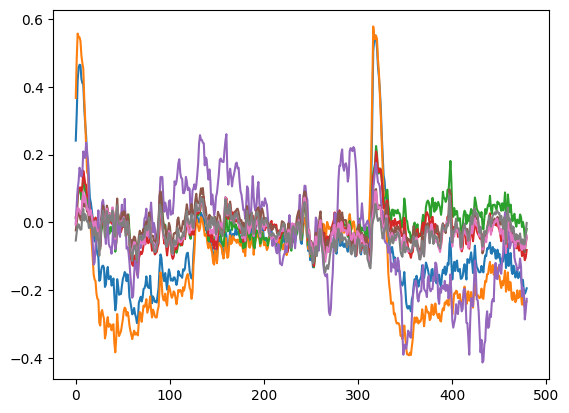

In [19]:
import matplotlib.pyplot as plt 

for i in range(len(X_train[0,:,0])):
    plt.plot(X_train[100,i,:])

array([1.])

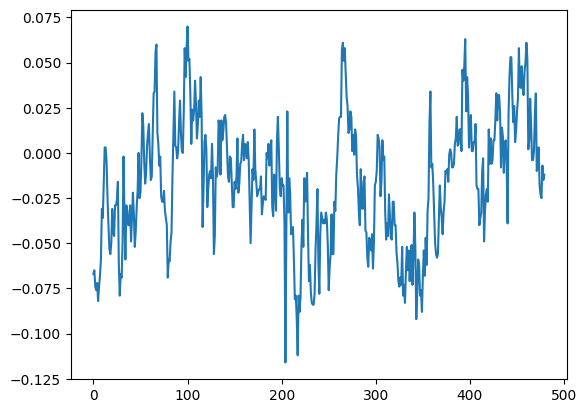

In [15]:
import matplotlib.pyplot as plt 
plt.plot(samples[0,0])

np.unique(subjects_val)

In [ ]:
#-------------------------------------------------------------------------------------------
#Entrenamiento del modelo global desde 0, con cross-validation, para los distintos canales
#-------------------------------------------------------------------------------------------
importlib.reload(EEG)

folds = 5
epochs=3

def lr_schedule(epoch):
    if epoch < 20: return 1e-2
    elif epoch < 40: return 2e-3
    elif epoch < 60: return 2e-4
    elif epoch < 80: return 4e-6
    else: return 4e-8


for Channels in (8,19,38,64):
    o_weights_folder=fr"C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\global_model_cv\cv{folds:.0f}_chan{Channels:.0f}_samples{Samples:.0f}_nbClasses{nb_classes}_ds{ds:.0f}"
    samples,labels,subjects = EEG.LoadDatabase(r"C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\Physionet",Channels)
    acc,val_acc = EEG.cvTrain(folds,samples,labels,subjects,outputFolder=o_weights_folder,lr_schedule=lr_schedule,epochs=epochs,Channels=Channels)

In [12]:
#-------------------------------------------------------------------------------------------
#Entrenamiento de sujeto específico.
#-------------------------------------------------------------------------------------------
importlib.reload(EEG)

Channels, Samples, nb_classes, ds = 64, 160, 4, 1
epochs=5
folds=4

#Es para saber qué pesos del modelo global usar de partida
def val_fold(subjectSpecific):
    if   subjectSpecific < 22: return 0
    elif subjectSpecific < 43: return 1
    elif subjectSpecific < 64: return 2
    elif subjectSpecific < 85: return 3
    else: return 4



samples,labels,subjects = EEG.LoadDatabase(r"C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\Physionet",Channels)



for subjectSpecific in np.unique(subjects):

    if subjectSpecific >87 :
        valFold = val_fold(subjectSpecific)
        print(f'sujeto: {subjectSpecific:.0f} || valFold: {valFold:.0f}')
        
        weightsFile = fr'C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\cv5_chan{Channels:.0f}_samples{Samples:.0f}_nbClasses{nb_classes:.0f}_ds{ds:.0f}\pesos_fold{valFold:.0f}.weights.h5'
        o_weights_folder=fr"C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\subjectSpecific\subjectSpecific{subjectSpecific:.0f}_cv{folds:.0f}_chan{Channels:.0f}_samples{Samples:.0f}_nbClasses{nb_classes}_ds{ds:.0f}"

        subjectSpecific_samples, subjectSpecific_labels, subjectSpecific_subjects = EEG.subjectSpecificData(subjectSpecific,samples[:,:,:Samples],labels,subjects)
        EEG.cvTrain(folds,subjectSpecific_samples,subjectSpecific_labels,subjectSpecific_subjects,o_weights_folder,weightsFile,lr_schedule,epochs=epochs,Channels=Channels,Samples=Samples,verbose=0)



sujeto: 89 || valFold: 4
 Equilibrio de clases: 0:6 1:5 2:5 3:5
 Equilibrio de clases: 0:5 1:6 2:5 3:5
 Equilibrio de clases: 0:5 1:5 2:6 3:5
 Equilibrio de clases: 0:5 1:5 2:5 3:6
Fold 0: sujetos validación: 89.0 - 89.0
Pesos cargados desde : C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\cv5_chan64_samples160_nbClasses4_ds1\pesos_fold4.weights.h5
Pesos cargados del archivo : C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\cv5_chan64_samples160_nbClasses4_ds1\pesos_fold4.weights.h5
Usando Learning Rate Scheduler : <function lr_schedule at 0x00000199136D3420>


c:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


accuracy en train: 0.952 || accuracy en val: 0.619
Fold 1: sujetos validación: 89.0 - 89.0
Pesos cargados desde : C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\cv5_chan64_samples160_nbClasses4_ds1\pesos_fold4.weights.h5
Pesos cargados del archivo : C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\cv5_chan64_samples160_nbClasses4_ds1\pesos_fold4.weights.h5
Usando Learning Rate Scheduler : <function lr_schedule at 0x00000199136D3420>
accuracy en train: 0.889 || accuracy en val: 0.667
Fold 2: sujetos validación: 89.0 - 89.0
Pesos cargados desde : C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\cv5_chan64_samples160_nbClasses4_ds1\pesos_fold4.weights.h5
Pesos cargados del archivo : C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\cv5_chan64_samples160_nbClasses4_ds1\pesos_fold4.weights.h5
Usando Learning Rate Scheduler : <function lr_schedule at 0x00000199136D3420>
accuracy en train: 0.889 || accuracy e

In [ ]:
#-------------------------------------------------------------------------------------------
#Representación Gráfica
#-------------------------------------------------------------------------------------------


importlib.reload(EEG)
folds = 5
Samples=480
nb_classes=4
ds=1

for Channels in (8,19,38,64):
    dataFolder = fr"C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\global_model_cv\cv{folds:.0f}_chan{Channels:.0f}_samples{Samples:.0f}_nbClasses{nb_classes}_ds{ds:.0f}"
    EEG.plotCvHistory(folds,dataFolder)




In [72]:
importlib.reload(EEG)

subjectSpecific_samples, subjectSpecific_labels, subjectSpecific_subjects = EEG.subjectSpecificData(110,samples,labels,subjects)

np.unique(subjects)

array([  1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,
        12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,
        23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,
        45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,  55.,
        56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,  66.,
        67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,  77.,
        78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,  89.,
        90.,  91.,  93.,  94.,  95.,  96.,  97.,  98.,  99., 101., 102.,
       103., 105., 106., 107., 108., 109.])

NameError: name 'EEG' is not defined